# UBBVA — Optimizador dinámico de tarifas con Deep Reinforcement Learning

## Contexto de negocio

UBBVA es una plataforma ficticia de movilidad compartida operada por BBVA México.
Como cualquier marketplace de viajes bajo demanda, enfrenta un desbalance constante
entre dos lados del mercado: los pasajeros que solicitan un viaje y los conductores
disponibles para atenderlo. Hoy la tarifa se fija únicamente en función de la
duración esperada del trayecto, lo cual ignora por completo las condiciones de
mercado del momento.

El problema es el mismo que resuelven Uber, DiDi o Lyft con su *surge pricing*:
cuando hay escasez de conductores, subir la tarifa raciona la demanda y atrae
oferta; cuando sobran conductores, bajarla activa viajes que de otro modo no
ocurrirían. La dificultad está en que **la decisión de hoy cambia las condiciones
de mañana**: un precio bajo agota la flota disponible y deja el siguiente viaje
en un escenario de escasez.

## Objetivo del reto

Entrenar una política de precios mediante Deep Q-Learning que supere, en ingreso
acumulado, a tres líneas base: la tarifa histórica, una política aleatoria y una
política miope que optimiza únicamente el viaje en curso.

## Datos

Dataset público de dynamic pricing (Kaggle, 1,000 registros históricos de viajes):
https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset

In [ ]:
# Revisando si mi configuración de PyTorch es correcta y si puedo usar MPS (Metal Performance Shaders) en mi Mac.
import torch
print(f"PyTorch: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"MPS construido: {torch.backends.mps.is_built()}")
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

PyTorch: 2.14.0
MPS disponible: True
MPS construido: True
Device: mps


In [2]:
# ─── Manipulación de datos ────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Preprocesamiento ─────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# ─── Visualización ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Deep Learning (bloques posteriores) ──────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

# ─── Utilidades ───────────────────────────────────────────────────────────
import random
from collections import deque, namedtuple
from itertools import product
from tqdm.notebook import tqdm
import warnings

# ─── Configuración global ─────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="GnBu_d")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}  |  PyTorch {torch.__version__}")

Matplotlib is building the font cache; this may take a moment.


Device: mps  |  PyTorch 2.14.0


## Cargando los datos con los que vamos a trabajar 

In [3]:
# Cargando los datros con los que vamos a trabajar
df = pd.read_csv("./Data/dynamic_pricing.csv")
print(f"Dimensiones: {df.shape}")
df.head(5)

Dimensiones: (1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## Haciendo el analisis exploratorio 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   str    
 3   Customer_Loyalty_Status  1000 non-null   str    
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   str    
 7   Vehicle_Type             1000 non-null   str    
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 78.3 KB


In [5]:
numerical_cols = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides',
                  'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']

categorical_cols = ['Location_Category', 'Customer_Loyalty_Status',
                    'Time_of_Booking', 'Vehicle_Type']

print("Valores únicos por categórica:")
for col in categorical_cols:
    print(f"  {col:28s} -> {sorted(df[col].unique())}")

print(f"\nNulos totales: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")


Valores únicos por categórica:
  Location_Category            -> ['Rural', 'Suburban', 'Urban']
  Customer_Loyalty_Status      -> ['Gold', 'Regular', 'Silver']
  Time_of_Booking              -> ['Afternoon', 'Evening', 'Morning', 'Night']
  Vehicle_Type                 -> ['Economy', 'Premium']

Nulos totales: 0
Duplicados: 0


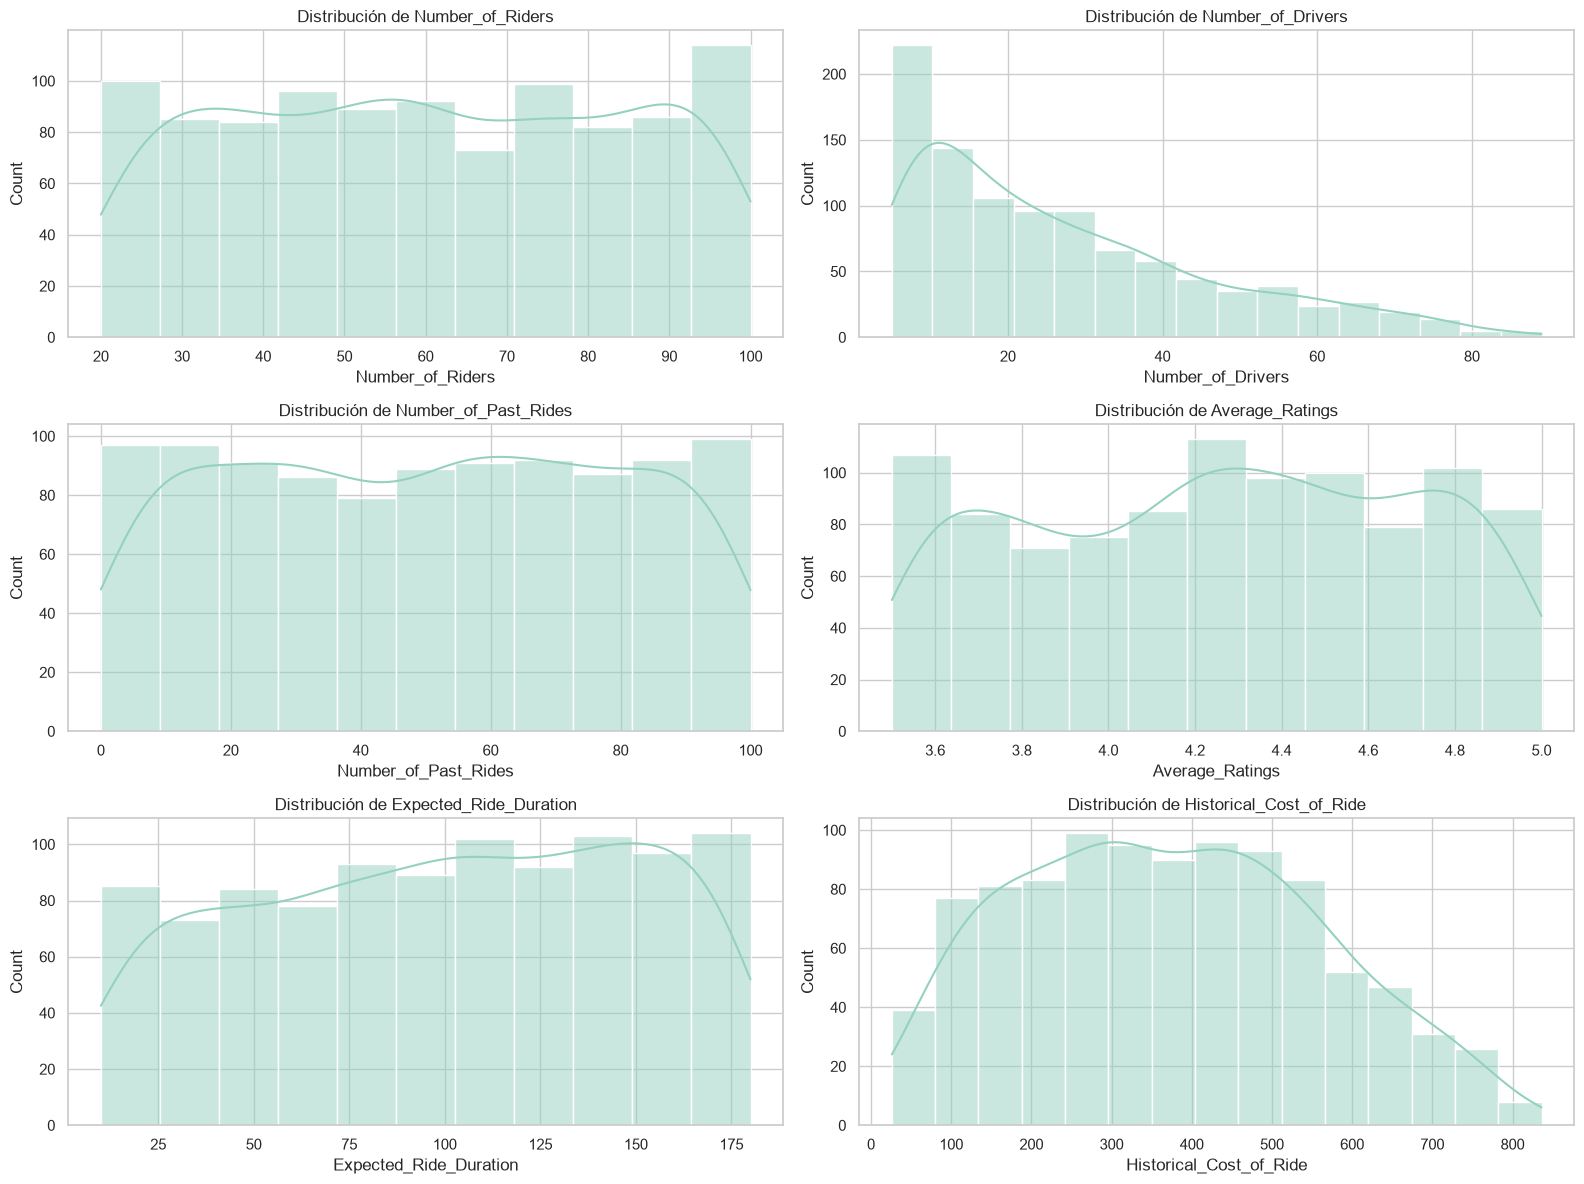

In [6]:
n_cols = 2
n_rows = len(numerical_cols) // n_cols + (len(numerical_cols) % n_cols > 0)

plt.figure(figsize=(16, 4 * n_rows))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df[column], kde=True)
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

In [7]:
df[numerical_cols].describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


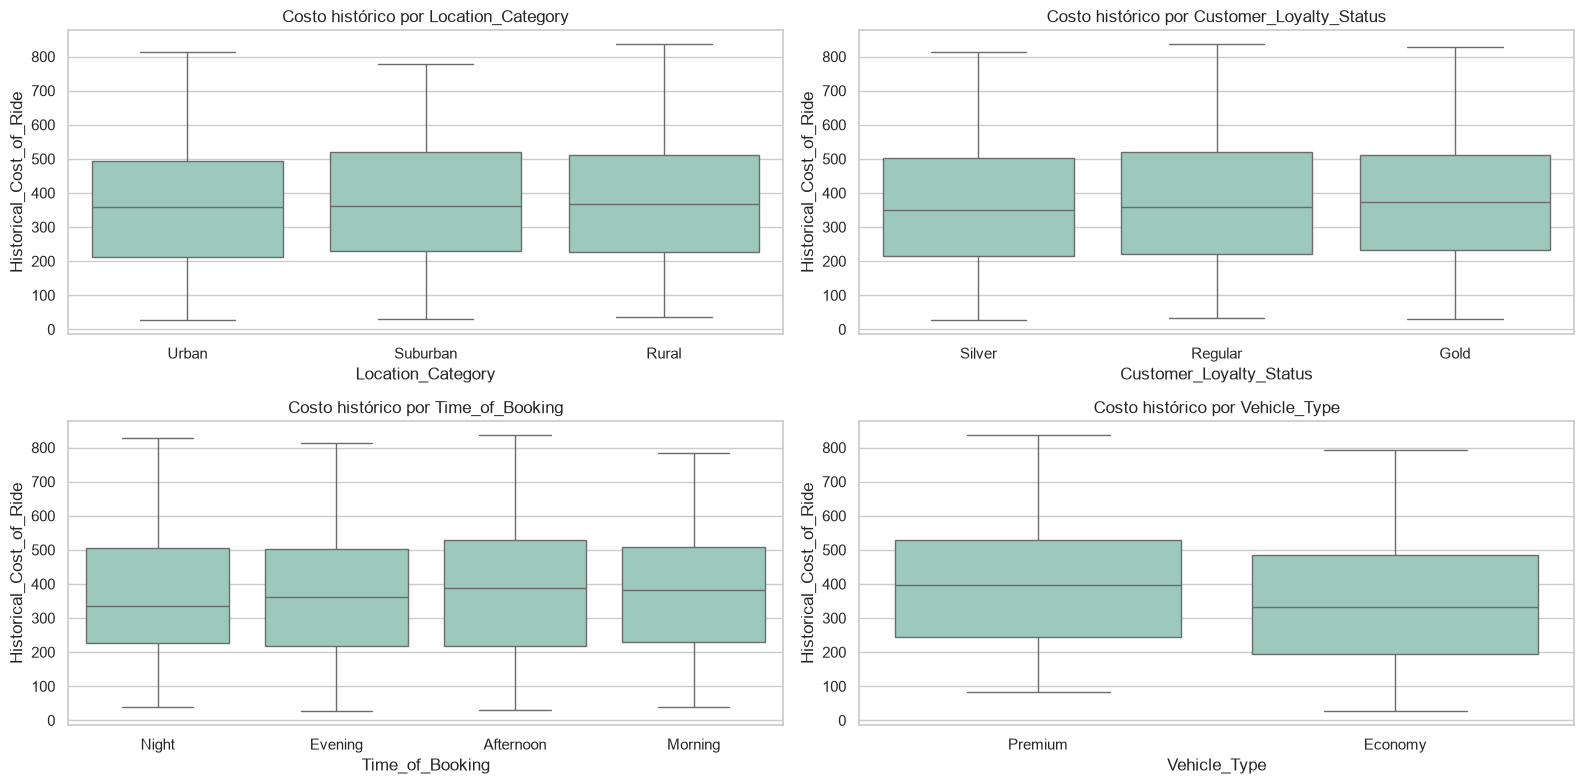

In [8]:
n_rows = len(categorical_cols) // n_cols + (len(categorical_cols) % n_cols > 0)

plt.figure(figsize=(16, 4 * n_rows))
for i, column in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=column, y='Historical_Cost_of_Ride', data=df)
    plt.title(f'Costo histórico por {column}')
plt.tight_layout()
plt.show()

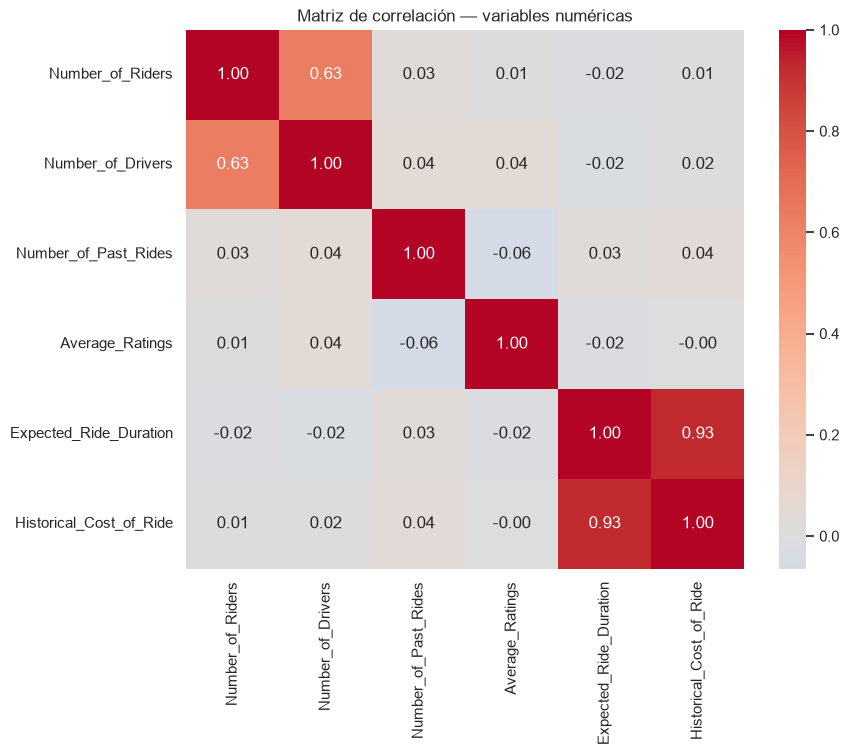

In [9]:
# Matriz de correlación sobre numéricas (sin one-hot, más legible)
plt.figure(figsize=(9, 7))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de correlación — variables numéricas')
plt.show()

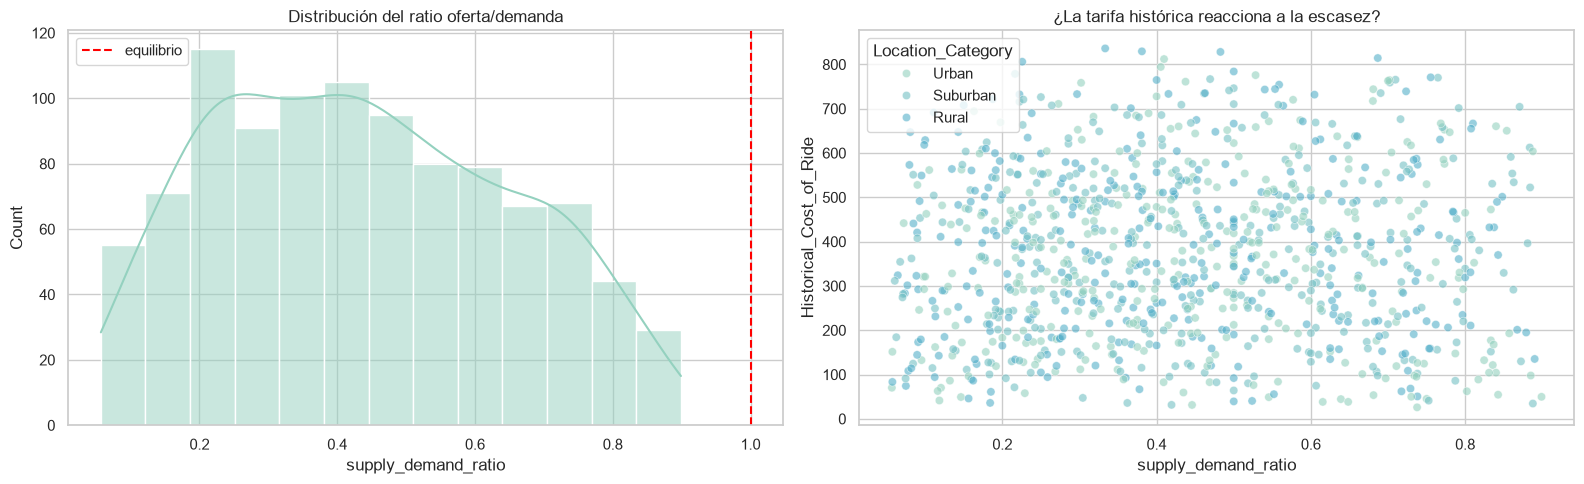

count    1000.000000
mean        0.438162
std         0.211650
min         0.056818
25%         0.263158
50%         0.424242
75%         0.602849
max         0.898990
Name: supply_demand_ratio, dtype: float64


In [10]:
# El ratio oferta/demanda es la variable que va a gobernar el MDP
df['supply_demand_ratio'] = df['Number_of_Drivers'] / df['Number_of_Riders']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['supply_demand_ratio'], kde=True, ax=axes[0])
axes[0].axvline(1.0, color='red', ls='--', label='equilibrio')
axes[0].set_title('Distribución del ratio oferta/demanda')
axes[0].legend()

sns.scatterplot(data=df, x='supply_demand_ratio', y='Historical_Cost_of_Ride',
                hue='Location_Category', alpha=0.6, ax=axes[1])
axes[1].set_title('¿La tarifa histórica reacciona a la escasez?')
plt.tight_layout()
plt.show()

print(df['supply_demand_ratio'].describe())

### Comentario de la gráfica

La gráfica muestra la relación entre la oferta y la demanda mediante el indicador `supply_demand_ratio`, calculado como el número de conductores dividido entre el número de pasajeros.

La línea roja representa el punto de equilibrio, donde existe un conductor por cada pasajero (`ratio = 1`). En este caso, todos los valores se encuentran por debajo de 1, lo que indica que hay menos conductores que pasajeros y, por lo tanto, existe una posible escasez de oferta.

El promedio del indicador es aproximadamente 0.44. Esto significa que, en promedio, hay menos de un conductor disponible por cada pasajero. Sin embargo, el diagrama de dispersión no muestra una relación clara entre este indicador y la tarifa histórica del viaje. Por esta razón, no se puede afirmar que la tarifa aumente directamente cuando hay escasez de conductores.

En conclusión, el desequilibrio entre conductores y pasajeros es una variable importante para analizar el comportamiento del servicio, pero sería necesario estudiar otras variables para determinar qué factores influyen realmente en la tarifa.

## Justificación empírica del proyecto


**1. La tarifa actual depende casi exclusivamente de la duración del viaje.**
La correlación entre `Expected_Ride_Duration` e `Historical_Cost_of_Ride` es de
**0.93**. Esto confirma numéricamente lo que afirma el enunciado del problema:
la política de precios vigente es esencialmente una función lineal de la duración.

**2. La tarifa actual ignora por completo las condiciones de mercado.**
La correlación de la tarifa con `Number_of_Riders` es de **0.01** y con
`Number_of_Drivers` de **0.02**. El diagrama de dispersión entre la tarifa y el
ratio oferta/demanda es una nube sin estructura. Con n = 1,000 observaciones,
esto no es "ausencia de evidencia": es evidencia de ausencia de relación.
Existe, por lo tanto, un espacio de mejora que ninguna política actual explota.

**3. El mercado opera permanentemente en escasez de conductores.**
El ratio `Number_of_Drivers / Number_of_Riders` tiene media 0.438 y **máximo
0.899**: nunca alcanza el equilibrio. La plataforma opera siempre con más
solicitudes que conductores disponibles, lo que convierte la asignación de
oferta en el recurso escaso a administrar.

**Por qué no un modelo supervisado.** El dataset no contiene ninguna etiqueta de
"tarifa óptima": solo registra lo que la empresa cobró. Un modelo supervisado
entrenado sobre `Historical_Cost_of_Ride` aprendería a reproducir una política
que, según los puntos 1 y 2, es subóptima por construcción. Tampoco existen
registros de precios alternativos, aceptación o rechazo, ni de disponibilidad
posterior de conductores, por lo que no es posible hacer inferencia causal ni
aprendizaje off-policy a partir de estos datos.

Lo que sí es posible es construir un **simulador explícito y documentado** del
mercado, y entrenar una política por interacción con él. Los datos históricos
aportan la distribución realista de contextos (zona, horario, vehículo, lealtad,
duración, tarifa de referencia); el simulador aporta la dinámica de respuesta.


## Decisiones sobre variables

### Variables excluidas de la primera versión del estado

| Variable | Correlación con la tarifa | Razón de exclusión |
|---|---:|---|
| `Average_Ratings` | -0.00 | Sin relación con el precio ni interpretación operativa clara. Su rol causal sobre la decisión de tarifa no es justificable. |
| `Number_of_Past_Rides` | 0.04 | Redundante con `Customer_Loyalty_Status`, que ya captura la antigüedad del cliente en forma segmentada y directamente utilizable en la función de recompensa. |

Estas exclusiones responden a criterios de **simplicidad y trazabilidad del
modelo**, no a que las variables carezcan de valor. En una segunda iteración,
`Average_Ratings` podría incorporarse como modulador de la probabilidad de
asignación de conductor.

### Colinealidad conocida y aceptada

`Expected_Ride_Duration` e `Historical_Cost_of_Ride` presentan una correlación
de **0.93**, por lo que ambas aportan esencialmente la misma señal. Se conservan
las dos de forma deliberada porque cumplen roles distintos en el modelo:

- `Historical_Cost_of_Ride` es la **tarifa de referencia** sobre la cual el
  agente aplica su ajuste porcentual. Es un insumo operativo, no una covariable.
- `Expected_Ride_Duration` es el **proxy de esfuerzo del viaje** y entra en la
  probabilidad de aceptación del pasajero: viajes largos son más caros en
  términos absolutos y por tanto más fáciles de rechazar.

Se documenta la redundancia para evitar que se interprete como un descuido. Una
red neuronal tolera predictores colineales sin problemas de identificación, a
diferencia de una regresión lineal.

RHO_REF   (mediana)        = 0.8241
RHO_SCALE (desv. robusta)  = 0.5842

Rango de rho estandarizada: [-1.23, 3.21]
count    1000.000
mean        0.185
std         0.951
min        -1.230
25%        -0.571
50%         0.000
75%         0.778
max         3.206
Name: rho, dtype: float64


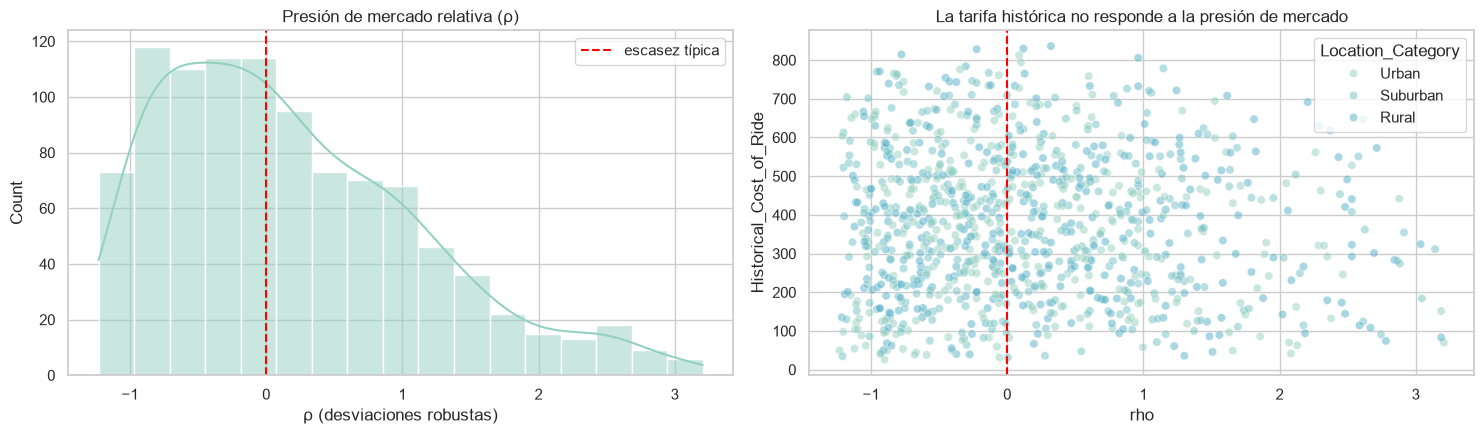

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# PRESIÓN DE MERCADO RELATIVA (ρ)
# ═══════════════════════════════════════════════════════════════════════════
# Definición original:  rho_raw = log((riders+1)/(drivers+1))
#
# Problema detectado en el EDA: el ratio drivers/riders nunca alcanza 1
# (máx = 0.899), por lo que rho_raw es SIEMPRE positivo. Interpretar rho = 0
# como "equilibrio de mercado" sería incorrecto: ese punto no existe en los
# datos y el agente nunca lo observaría.
#
# Corrección: se conserva la forma logarítmica (que hace simétricos los
# desbalances en ambas direcciones y comprime la cola de escasez extrema),
# pero se reancla el origen en la MEDIANA OBSERVADA y se escala con una
# desviación robusta. La lectura pasa a ser relativa a la propia plataforma:
#
#   rho <  0  →  escasez MENOR a la habitual (oferta relativamente holgada)
#   rho =  0  →  escasez típica de UBBVA
#   rho >  0  →  escasez MAYOR a la habitual (presión de demanda inusual)
#
# Beneficio adicional: al quedar centrada y con escala unitaria, los
# coeficientes de las sigmoides del simulador operan sobre una escala
# interpretable (un punto de rho = una desviación robusta).
# ═══════════════════════════════════════════════════════════════════════════

df['rho_raw'] = np.log((df['Number_of_Riders'] + 1) / (df['Number_of_Drivers'] + 1))

RHO_REF   = df['rho_raw'].median()
RHO_SCALE = (df['rho_raw'].quantile(0.75) - df['rho_raw'].quantile(0.25)) / 1.349

df['rho'] = (df['rho_raw'] - RHO_REF) / RHO_SCALE

print(f"RHO_REF   (mediana)        = {RHO_REF:.4f}")
print(f"RHO_SCALE (desv. robusta)  = {RHO_SCALE:.4f}")
print(f"\nRango de rho estandarizada: [{df['rho'].min():.2f}, {df['rho'].max():.2f}]")
print(df['rho'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(df['rho'], kde=True, ax=axes[0])
axes[0].axvline(0, color='red', ls='--', label='escasez típica')
axes[0].set_title('Presión de mercado relativa (ρ)')
axes[0].set_xlabel('ρ (desviaciones robustas)')
axes[0].legend()

sns.scatterplot(data=df, x='rho', y='Historical_Cost_of_Ride',
                hue='Location_Category', alpha=0.5, ax=axes[1])
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('La tarifa histórica no responde a la presión de mercado')
plt.tight_layout(); plt.show()

## Formulación del proceso de decisión de Markov

El problema se modela como una tupla $M = (S, A, p, r)$ donde una jornada de
operación consiste en atender secuencialmente $H$ solicitudes de viaje.

### Estado

$$s_t = [\,\text{riders}_t,\ \text{drivers}_t,\ \rho_t,\ \text{zona},\ \text{hora},\ \text{vehículo},\ \text{lealtad},\ \text{duración},\ \text{tarifa base}\,]$$

El estado tiene **dos componentes de naturaleza distinta**, y esa separación es
el núcleo del diseño:

- **Componente endógeno** — `riders`, `drivers` y su derivada `ρ`. Estas
  variables *arrastran* de un paso al siguiente y son modificadas por la acción
  del agente. Aquí es donde reside la estructura temporal del problema.
- **Componente exógeno** — zona, horario, tipo de vehículo, lealtad, duración y
  tarifa base. Se muestrean de una fila histórica nueva en cada paso. Describen
  la solicitud que llega, sobre la cual el agente no tiene control.

### Acciones

$$\delta_t \in \{-0.30,\ -0.20,\ -0.10,\ 0,\ +0.10,\ +0.20,\ +0.30\}, \qquad p_t = p_{0,t}\,(1 + \delta_t)$$

Los ajustes son relativos a la tarifa de referencia y **no son acumulativos**
entre pasos: la cotización siempre queda entre el 70% y el 130% de la referencia.

### Transición

Cada paso ejecuta la siguiente secuencia:

1. Observar $s_t$.
2. Elegir $\delta_t$ y calcular la tarifa ofrecida $p_t$.
3. Simular la aceptación del pasajero: $B_t \sim \text{Bernoulli}(P(B_t \mid s_t, a_t))$.
4. Si aceptó, simular la asignación de conductor: $M_t \sim \text{Bernoulli}(P(M_t \mid s_t, a_t))$.
5. El viaje se completa si $Y_t = B_t \cdot M_t = 1$.
6. Calcular la recompensa $r_t$.
7. Actualizar riders y drivers; muestrear una nueva fila para el componente exógeno.

La dinámica de la parte endógena es:

$$\text{drivers}_{t+1} = \text{clip}\Big(\text{drivers}_t - Y_t + \text{entrada}_t + \kappa\,\max(0,\delta_t),\ d_{\min},\ d_{\max}\Big)$$

$$\text{riders}_{t+1} = \text{clip}\Big(\text{riders}_t - Y_t - \text{abandono}_t + \text{llegadas}_t,\ r_{\min},\ r_{\max}\Big)$$

**Qué implica cada término.** Un viaje completado consume simultáneamente un
pasajero y un conductor: la operación desgasta su propio inventario. Los
términos de entrada y llegadas son la reposición estocástica del mercado, sin la
cual el pool se agotaría y los episodios largos degenerarían. El término
$\kappa\,\max(0,\delta_t)$ codifica el supuesto central del *surge pricing*:
**una tarifa elevada atrae conductores adicionales a la plataforma**.

Ese último término es lo que convierte el problema en un MDP genuino y no en una
secuencia de decisiones independientes. Subir el precio reduce la probabilidad
de cerrar el viaje actual, pero mejora la disponibilidad de flota para los
siguientes. El agente enfrenta un trade-off intertemporal real, y por lo tanto
el factor de descuento $\gamma$ tiene contenido: sin este acoplamiento, el
problema colapsaría a un bandido contextual y la ecuación de Bellman sería
redundante.

### Recompensa

$$r_t = Y_t\,\tilde p_t \;-\; \lambda_{\text{pérdida}}\,(1 - Y_t)\,\tilde p_t \;-\; \lambda_{\text{ret}}\,\max(0,\delta_t)\,g(L_t)$$

El costo de oportunidad es **proporcional a la tarifa perdida**: dejar escapar
un viaje caro daña más la rentabilidad que dejar escapar uno barato. El tercer
término penaliza aplicar sobreprecio a clientes valiosos, con $g$ creciente en
el nivel de lealtad. La lealtad no altera la tarifa base; solo encarece el
sobreprecio sobre segmentos que conviene retener.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL SIMULADOR
# Todos los supuestos del entorno viven aquí. Ningún número mágico
# debe aparecer fuera de este bloque.
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# MODIFICACIÓN 1 — Espacio de acciones asimétrico
# ═══════════════════════════════════════════════════════════════════════════
# El diagnóstico del mapa miope mostró que la restricción superior estaba
# activa en 44% de los contextos: el agente quería cobrar más de +30% y el
# espacio de acciones se lo impedía.
#
# Se amplía el techo a +50%, pero NO se amplía el piso. Razón empírica: al
# probar un rango simétrico [-50%, +50%], las acciones -0.40 y -0.50 no
# resultaron óptimas en NINGUNO de los 81 contextos evaluados. Serían dos
# salidas muertas de la red consumiendo presupuesto de exploración.
#
# Razón económica: el descuento tiene rendimientos decrecientes rápidos
# (sacrificar margen sobre un cliente que ya aceptaría), mientras que el
# sobreprecio escala bien bajo escasez porque la demanda se vuelve inelástica
# y además atrae oferta.
#
# Costo de añadir acciones: con ε-greedy uniforme cada acción recibe ε/|A|
# del presupuesto de exploración. 9 acciones asimétricas cubren el mismo
# rango útil que 11 simétricas, con 2 estimaciones menos que aprender.
# ═══════════════════════════════════════════════════════════════════════════
DELTAS = np.array([-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30, 0.40, 0.50])
N_ACTIONS = len(DELTAS)


# ── Episodio ───────────────────────────────────────────────────────────────
# Reducido de 20 a 10 pasos: con mediana de ~20 conductores y tasa de
# finalización ~0.64, 20 pasos drenaban el pool y los episodios que
# arrancaban con pocos conductores degeneraban. Parámetro para experimentar.
EPISODE_STEPS = 10          # rango razonable a explorar: 5 – 25

# ── Aceptación del pasajero:  P(B=1) = σ(b0 + b1·ρ − b2(ρ)·δ + b3·L − b4·D) ─
B0        = 1.20   # intercepto. σ(1.20)=0.77 → aceptación base en δ=0
B1_RHO    = 0.45   # escasez ↑ → pasajero más dispuesto. ρ en desv. robustas
B2_BASE   = 4.00   # sensibilidad al precio en escasez típica (ρ=0)
B2_RHO    = 1.20   # INTERACCIÓN: la elasticidad CAE con la escasez
# ═══════════════════════════════════════════════════════════════════════════
# MODIFICACIÓN 2 — Piso de elasticidad
# ═══════════════════════════════════════════════════════════════════════════
# Con B2_CLIP = (1.0, 8.0), la sensibilidad efectiva al precio caía a 1.0 bajo
# escasez extrema: demanda casi perfectamente inelástica. En ese régimen el
# ingreso esperado crece monótonamente con δ y el óptimo SIEMPRE cae en el
# borde superior del espacio de acciones, sin importar dónde se ponga ese
# borde. El resultado era un bloque saturado sin estructura que aprender.
#
# Al elevar el piso a 2.0 se mantiene una elasticidad residual: incluso en
# escasez máxima el pasajero reacciona al precio. Esto genera un ÓPTIMO
# INTERIOR y convierte el bloque plano en un gradiente real
# (+0.20 → +0.30 → +0.40 → +0.50), que es justamente la estructura fina que
# la red neuronal debe capturar.
#
# Efecto medido: contextos con la restricción activa 44.4% → 17.3%
# ═══════════════════════════════════════════════════════════════════════════
B2_CLIP = (2.0, 8.0)  # cotas de la sensibilidad efectiva
B3_LOY    = 0.40   # lealtad ↑ → más tolerante. L ∈ {0, 0.5, 1}
B4_DUR    = 0.60   # viaje largo → más caro en absoluto → más rechazo. D ∈ [0,1]

# ── Match de conductor:  P(M=1) = σ(e0 − e1·ρ + e2·max(0,δ) + e_zona) ──────
E0        = 1.80   # intercepto. σ(1.80)=0.86
E1_RHO    = 0.50   # escasez ↑ → más difícil conseguir conductor
E2_SURGE  = 3.00   # sobreprecio atrae conductores (mecanismo del surge)
E_ZONA    = {'Urban': 0.0, 'Suburban': -0.40, 'Rural': -0.90}   # fricción espacial

# ── Dinámica de oferta y demanda ───────────────────────────────────────────
KAPPA_SURGE   = 2.0    # conductores atraídos por δ=+1.0 (escala lineal)
DRIVER_INFLOW = 0.8    # media Poisson de entrada de conductores por paso
RIDER_INFLOW  = 1.5    # media Poisson de llegada de pasajeros por paso
P_ABANDONO    = 0.35   # prob. de que un pasajero rechazado abandone
DRIVERS_RANGE = (3, 90)
RIDERS_RANGE  = (15, 110)

# ── Recompensa ─────────────────────────────────────────────────────────────
LAMBDA_PERDIDA   = 0.40   # costo de oportunidad, proporcional a la tarifa
# ═══════════════════════════════════════════════════════════════════════════
# MODIFICACIÓN 3 — Penalización de retención
# ═══════════════════════════════════════════════════════════════════════════
# Valor anterior (0.20): insuficiente. El castigo por aplicar +30% a un
# cliente Gold era 0.20 × 0.30 × 1.00 = 0.06 contra un ingreso de ~0.56,
# apenas 10%. No alcanzaba para mover el argmax y los tres segmentos de
# lealtad recibían el mismo trato en escasez.
#
# Se evaluaron λ ∈ {0.2, 0.3, 0.4, 0.5, 0.6, 0.8}:
#   λ = 0.8  → SOBRE-CORRIGE. El cliente Gold queda congelado en δ = 0.00 en
#              todo el rango de escasez; la lealtad deja de ser un matiz y se
#              vuelve una prohibición. Política plana en 1/3 del espacio.
#   λ = 0.5  → ÓPTIMO. Tres escalas de agresividad claramente diferenciadas:
#              Regular alcanza +0.50, Silver llega con ~2 columnas de retraso,
#              Gold queda topado en +0.30 y solo bajo escasez extrema.
#
# Efecto medido: la lealtad cambia la acción óptima en 33.3% → 85.2% de los
# contextos. La variable deja de ser decorativa en el estado.
# ═══════════════════════════════════════════════════════════════════════════
LAMBDA_RETENCION = 0.50  # castigo por sobreprecio a clientes valiosos
G_LEALTAD = {'Regular': 0.25, 'Silver': 0.60, 'Gold': 1.00}
L_NUM     = {'Regular': 0.0,  'Silver': 0.50, 'Gold': 1.00}   # L en la sigmoide

# ── Escalas de normalización (se calculan desde los datos) ─────────────────
P_SCALE = df['Historical_Cost_of_Ride'].max()   # tarifa normalizada p̃ = p / P_SCALE
D_SCALE = df['Expected_Ride_Duration'].max()    # duración normalizada D ∈ [0,1]

print(f"P_SCALE = {P_SCALE:.2f}   |   D_SCALE = {D_SCALE:.2f}")
print(f"Tarifa normalizada media: {(df['Historical_Cost_of_Ride']/P_SCALE).mean():.3f}")

P_SCALE = 836.12   |   D_SCALE = 180.00
Tarifa normalizada media: 0.446


In [13]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def p_acepta(rho, delta, loyalty, dur_norm):
    """
    Probabilidad de que el pasajero acepte la tarifa ofrecida.

    La sensibilidad al precio b2 DEPENDE de la escasez: bajo presión de
    demanda el pasajero tiene menos alternativas y se vuelve menos elástico.
    Esta interacción es lo que hace que la acción óptima varíe con el estado;
    sin ella, el argmax sobre acciones sería prácticamente constante.
    """
    b2 = np.clip(B2_BASE - B2_RHO * rho, *B2_CLIP)
    z  = B0 + B1_RHO * rho - b2 * delta + B3_LOY * L_NUM[loyalty] - B4_DUR * dur_norm
    return sigmoid(z)


def p_match(rho, delta, zona):
    """
    Probabilidad de asignar un conductor, dado que el pasajero ya aceptó.

    Decrece con la escasez y crece con el sobreprecio (mecanismo de surge).
    El término de zona introduce fricción espacial: fuera del núcleo urbano
    la densidad de conductores es menor y el match es más difícil.
    """
    z = E0 - E1_RHO * rho + E2_SURGE * max(0.0, delta) + E_ZONA[zona]
    return sigmoid(z)


def recompensa(completado, precio_norm, delta, loyalty):
    """
    r = Y·p̃  −  λ_pérdida·(1−Y)·p̃  −  λ_retención·max(0,δ)·g(L)

    El costo de oportunidad es proporcional a la tarifa: perder un viaje caro
    daña más la rentabilidad que perder uno barato.
    """
    ingreso    = completado * precio_norm
    oportunidad = LAMBDA_PERDIDA * (1 - completado) * precio_norm
    retencion   = LAMBDA_RETENCION * max(0.0, delta) * G_LEALTAD[loyalty]
    return ingreso - oportunidad - retencion


def recompensa_esperada(rho, delta, loyalty, dur_norm, zona, p0_norm):
    """Versión analítica: E[r] promediando sobre B y M. Se usa para calibrar."""
    pY = p_acepta(rho, delta, loyalty, dur_norm) * p_match(rho, delta, zona)
    p_tilde = p0_norm * (1 + delta)
    return (pY * p_tilde
            - LAMBDA_PERDIDA * (1 - pY) * p_tilde
            - LAMBDA_RETENCION * max(0.0, delta) * G_LEALTAD[loyalty])

C1 — acciones que llegan a ser óptimas: [np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3)]
     7 de 7 acciones. PASA

C2 — brecha mejor vs peor acción:
     mediana = 0.1367   mínima = 0.0353
     PASA

C3 — fracción de contextos donde la zona cambia la acción óptima:    22.22%
     fracción donde la lealtad cambia la acción óptima:              33.33%


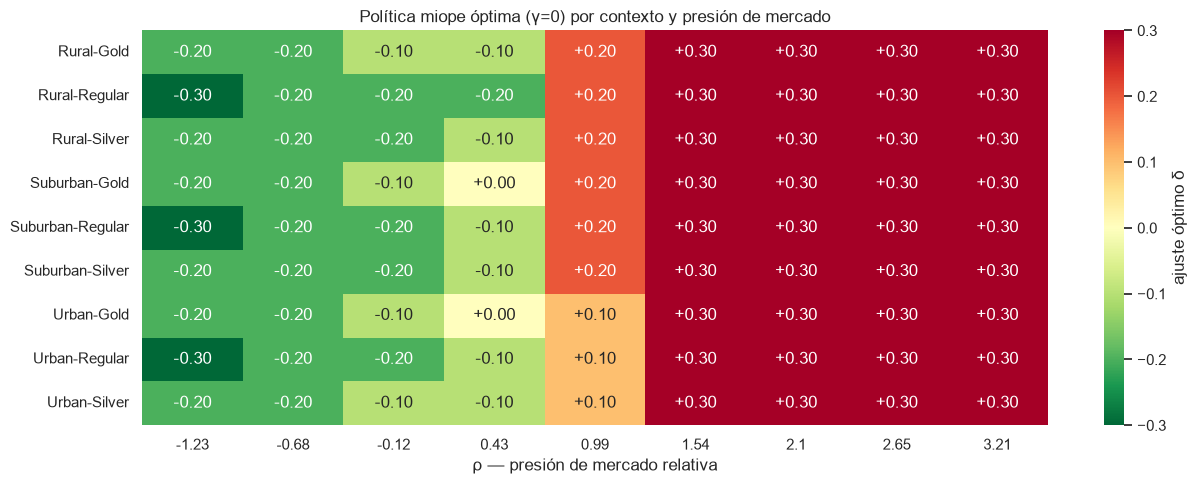

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CHECKPOINT DE CALIBRACIÓN DEL ENTORNO
#
# Antes de entrenar cualquier red, verificamos por fuerza bruta que el
# entorno plantee un problema de decisión no trivial. Tres criterios:
#
#   C1. La acción óptima CAMBIA con el estado. Si fuera constante, el
#       problema se resolvería con una regla fija y no habría nada que
#       aprender.
#   C2. La brecha entre la mejor y la peor acción es MATERIAL. Si fuera
#       marginal, el ruido de la simulación dominaría la señal.
#   C3. La política óptima varía también por zona y por lealtad, lo que
#       confirma que esas variables del estado son informativas.
# ═══════════════════════════════════════════════════════════════════════════

rho_grid = np.round(np.linspace(df['rho'].min(), df['rho'].max(), 9), 2)
p0_medio = (df['Historical_Cost_of_Ride'] / P_SCALE).median()
dur_media = (df['Expected_Ride_Duration'] / D_SCALE).median()

filas = []
for zona in ['Urban', 'Suburban', 'Rural']:
    for loy in ['Regular', 'Silver', 'Gold']:
        for rho in rho_grid:
            vals = np.array([recompensa_esperada(rho, d, loy, dur_media, zona, p0_medio)
                             for d in DELTAS])
            filas.append({
                'zona': zona, 'lealtad': loy, 'rho': rho,
                'delta_optimo': DELTAS[vals.argmax()],
                'brecha': vals.max() - vals.min(),
                'E_r_max': vals.max(),
                'p_completa': p_acepta(rho, DELTAS[vals.argmax()], loy, dur_media)
                              * p_match(rho, DELTAS[vals.argmax()], zona),
            })

calib = pd.DataFrame(filas)

# ── C1: ¿cuántas acciones distintas llegan a ser óptimas? ──────────────────
acciones_usadas = sorted(calib['delta_optimo'].unique())
print(f"C1 — acciones que llegan a ser óptimas: {acciones_usadas}")
print(f"     {len(acciones_usadas)} de {N_ACTIONS} acciones. "
      f"{'PASA' if len(acciones_usadas) >= 4 else 'FALLA: entorno degenerado'}")

# ── C2: ¿la brecha es material? ───────────────────────────────────────────
print(f"\nC2 — brecha mejor vs peor acción:")
print(f"     mediana = {calib['brecha'].median():.4f}   mínima = {calib['brecha'].min():.4f}")
print(f"     {'PASA' if calib['brecha'].median() > 0.05 else 'FALLA: señal demasiado débil'}")

# ── C3: ¿las covariables categóricas importan? ────────────────────────────
var_zona = calib.groupby(['lealtad','rho'])['delta_optimo'].nunique().gt(1).mean()
var_loy  = calib.groupby(['zona','rho'])['delta_optimo'].nunique().gt(1).mean()
print(f"\nC3 — fracción de contextos donde la zona cambia la acción óptima:    {var_zona:.2%}")
print(f"     fracción donde la lealtad cambia la acción óptima:              {var_loy:.2%}")

# ── Mapa de la política miope óptima ──────────────────────────────────────
pivot = calib.pivot_table(index=['zona','lealtad'], columns='rho', values='delta_optimo')
plt.figure(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='+.2f', cmap='RdYlGn_r', center=0,
            cbar_kws={'label': 'ajuste óptimo δ'})
plt.title('Política miope óptima (γ=0) por contexto y presión de mercado')
plt.xlabel('ρ — presión de mercado relativa'); plt.ylabel('')
plt.tight_layout(); plt.show()

## Lectura del mapa de política miope

El mapa de calor anterior resume 81 contextos: 9 combinaciones de zona y nivel
de lealtad, evaluadas sobre 9 niveles de presión de mercado. En cada celda se
reporta el ajuste de precio $\delta$ que **maximiza la recompensa esperada de
un solo paso**, calculado analíticamente sin simulación ni entrenamiento:

$$\mathbb{E}[r \mid s, \delta] = P(Y=1 \mid s,\delta)\,\tilde p \;-\; \lambda_{\text{pérdida}}\,\big(1 - P(Y=1 \mid s,\delta)\big)\,\tilde p \;-\; \lambda_{\text{ret}}\max(0,\delta)\,g(L)$$

### El gradiente horizontal: surge pricing emergente

Todas las filas transitan de verde a rojo conforme aumenta $\rho$. Cuanto mayor
la presión de demanda, mayor el sobreprecio óptimo. **Este comportamiento no fue
programado**: no existe ninguna regla del tipo "si hay escasez, sube el precio".
Emerge de la interacción entre dos supuestos independientes del simulador.

El mecanismo es doble y ambos efectos apuntan en la misma dirección:

| | Oferta holgada ($\rho \approx 0$) | Escasez fuerte ($\rho \approx 2$) |
|---|---:|---:|
| Sensibilidad efectiva al precio $\beta_2(\rho)$ | 4.14 | 1.48 |
| Caída de aceptación al barrer todo el rango de $\delta$ | −49 pp | −11 pp |
| Ganancia en probabilidad de match por sobreprecio | +7 pp | +16 pp |

Con oferta holgada, subir el precio destruye casi la mitad de la conversión: el
pasajero tiene alternativas y se va. Bajo escasez la demanda se vuelve
inelástica —el mismo movimiento de precio cuesta solo 11 puntos de aceptación—
y además el sobreprecio **atrae conductores adicionales**, mejorando la
probabilidad de asignación. Ingreso unitario, conversión y disponibilidad de
oferta dejan de estar en conflicto.

### El salto discreto

La transición de descuento a sobreprecio ocurre de golpe entre dos columnas
contiguas. No es un artefacto numérico: la recompensa esperada varía de forma
continua con $\rho$, pero el mapa reporta el $\arg\max$ sobre un conjunto
**finito** de acciones. Un óptimo que se desplaza suavemente sobre una función
continua produce, al discretizarse, un umbral. Es el mismo fenómeno que separa
una probabilidad continua de una etiqueta asignada en clasificación.

### La franja de transición

Alrededor del umbral, las acciones adyacentes rinden casi lo mismo y la brecha
entre la mejor y la peor se reduce a su mínimo. Esto tiene una implicación
práctica para la evaluación posterior: es la región donde la política aprendida
mostrará mayor desacuerdo con este mapa, y también aquella donde equivocarse
tiene el menor costo. Los desacuerdos concentrados en esa franja no deben
interpretarse como falla del agente.

### Lectura vertical por zona

Las zonas suburbana y rural adoptan sobreprecio **antes y con mayor intensidad**
que la urbana. La razón está en la fricción espacial del término $\eta_{\text{zona}}$:
fuera del núcleo urbano la probabilidad de conseguir conductor es
estructuralmente menor, y el sobreprecio es el único instrumento del que dispone
el agente para recuperar disponibilidad de oferta. En zona urbana la densidad de
conductores resuelve el problema sin necesidad de pagar por ella.

### Lectura vertical por lealtad

Los clientes de mayor lealtad reciben **descuentos menores** en el régimen de
oferta holgada. Esto, que parece contraintuitivo, es correcto: el coeficiente
$\beta_3$ los hace más tolerantes al precio, de modo que no es necesario
sacrificar margen para cerrar la operación. El descuento es un instrumento de
persuasión, y no se persuade a quien ya está convencido.

En el régimen de escasez, en cambio, la penalización de retención se activa y
los segmentos valiosos quedan protegidos del sobreprecio agresivo: el techo de
$\delta$ aplicable a un cliente Gold es sensiblemente menor que el aplicable a
un cliente Regular. Esta asimetría es una decisión de negocio explícita,
parametrizada por $\lambda_{\text{ret}}$ y $g(L)$, no una consecuencia accidental
del modelo.

### Restricción activa en los extremos

Cuando el mapa presenta bloques uniformes en el valor máximo de $\delta$, la
restricción del espacio de acciones está **activa**: el óptimo no restringido se
encuentra fuera del rango permitido. Esto no invalida el modelo —un tope al
sobreprecio es una restricción de negocio legítima, presente en la operación
real de las plataformas de movilidad por razones regulatorias y reputacionales—
pero debe documentarse, porque explica la saturación visual del mapa y previene
interpretar un estancamiento del desempeño como limitación del algoritmo.

### Función de este mapa en el proyecto

Este es el desempeño óptimo alcanzable **optimizando viaje por viaje**, es decir,
con factor de descuento $\gamma = 0$. Constituye la línea base *greedy miope*
contra la cual se evaluará la política aprendida, y cumple el papel de hipótesis
nula del proyecto:

> Si la red entrenada reproduce este mapa, no habrá aprendido nada que una tabla
> de consulta no resolviera. Si lo supera, será porque incorporó información que
> el mapa no contiene: la dinámica intertemporal del mercado.

El mapa desconoce que cada viaje completado consume un conductor del inventario
y deteriora las condiciones del siguiente paso. Una política con $\gamma$ alto
debería aplicar sobreprecio **antes y con mayor intensidad** que el óptimo
miope, sacrificando conversión inmediata para preservar disponibilidad de flota
a lo largo del episodio. La divergencia entre ambos mapas es el resultado
central que se busca documentar.